In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("=== UNLOCKING HOLDOUT: 2024-2025 ===")
print("This is a ONE-TIME test. Results are final.\n")

# Load holdout
holdout = pd.read_parquet('../data/holdout_locked/equities_holdout.parquet')
holdout['date'] = pd.to_datetime(holdout['date'])
print(f"Holdout: {len(holdout):,} rows, {holdout['ticker'].nunique()} tickers")
print(f"Date range: {holdout['date'].min().date()} to {holdout['date'].max().date()}")

# Load training data (need trailing history for signal computation)
train = pd.read_parquet('../data/working/equities_train.parquet')
train['date'] = pd.to_datetime(train['date'])

# Combine train + holdout for signal computation
# (signals at Jan 2024 need data from 2023 for lookbacks)
full = pd.concat([train, holdout], ignore_index=True)
full = full.sort_values(['ticker', 'date']).reset_index(drop=True)
print(f"\nFull panel: {len(full):,} rows")

# Membership
membership = pd.read_parquet('../data/raw/membership_panel.parquet')
membership['snapshot_date'] = pd.to_datetime(membership['snapshot_date'])
membership['month'] = membership['snapshot_date'].dt.to_period('M').dt.to_timestamp()

# Benchmark holdout
bench_h = pd.read_parquet('../data/holdout_locked/benchmark_holdout.parquet')
bench_h['date'] = pd.to_datetime(bench_h['date'])

# Full benchmark for continuous series
bench_all = pd.concat([
    pd.read_parquet('../data/working/benchmark_train.parquet').assign(date=lambda x: pd.to_datetime(x['date'])),
    bench_h
])
bench_monthly_all = (bench_all[bench_all['field'] == 'TOT_RETURN_INDEX_GROSS_DVDS']
                     .sort_values('date')
                     .assign(month=lambda x: x['date'].dt.to_period('M').dt.to_timestamp())
                     .groupby('month')['value']
                     .last()
                     .pct_change()
                     .rename('bench_ret'))

# SONIA holdout
sonia_h = pd.read_parquet('../data/holdout_locked/sonia_holdout.parquet')
sonia_h['date'] = pd.to_datetime(sonia_h['date'])
sonia_all = pd.concat([
    pd.read_parquet('../data/working/sonia_train.parquet').assign(date=lambda x: pd.to_datetime(x['date'])),
    sonia_h
])
sonia_monthly_all = (sonia_all.assign(month=sonia_all['date'].dt.to_period('M').dt.to_timestamp())
                     .groupby('month')['value']
                     .mean()
                     .rename('sonia_annual'))
sonia_monthly_all = sonia_monthly_all / 100 / 12

print("Benchmark and SONIA loaded for full period including holdout")

=== UNLOCKING HOLDOUT: 2024-2025 ===
This is a ONE-TIME test. Results are final.

Holdout: 207,412 rows, 426 tickers
Date range: 2024-01-01 to 2025-12-31

Full panel: 1,893,443 rows
Benchmark and SONIA loaded for full period including holdout


In [2]:
# Monthly returns from full panel
full['month'] = full['date'].dt.to_period('M')
monthly_full = (full.dropna(subset=['TOT_RETURN_INDEX_GROSS_DVDS'])
                .sort_values(['ticker', 'date'])
                .groupby(['ticker', 'month'])
                .last()
                .reset_index())
monthly_full = monthly_full.sort_values(['ticker', 'month']).reset_index(drop=True)
monthly_full['monthly_ret'] = monthly_full.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS'].pct_change()

# Signal 1: Momentum (12-month skip-1)
monthly_full['tr_lag2'] = monthly_full.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS'].shift(1)
monthly_full['tr_lag13'] = monthly_full.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS'].shift(12)
monthly_full['momentum_12_1'] = monthly_full['tr_lag2'] / monthly_full['tr_lag13'] - 1

# Signal 2: Reversal (1-month)
monthly_full['reversal_1m'] = monthly_full.groupby('ticker')['monthly_ret'].shift(1)

# Signal 3: Low-volatility (90-day realised vol)
print("Computing 90-day volatility (1-2 minutes)...")
full_sorted = full.sort_values(['ticker', 'date']).copy()
full_sorted['daily_ret'] = full_sorted.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS'].pct_change()
full_sorted['vol_90d'] = (full_sorted.groupby('ticker')['daily_ret']
                          .transform(lambda x: x.rolling(90, min_periods=60).std())
                          * np.sqrt(252))

vol_monthly_full = (full_sorted.dropna(subset=['vol_90d'])
                    .assign(month=full_sorted['date'].dt.to_period('M'))
                    .sort_values(['ticker', 'date'])
                    .groupby(['ticker', 'month'])['vol_90d']
                    .last()
                    .reset_index())
monthly_full = monthly_full.merge(vol_monthly_full, on=['ticker', 'month'], how='left')

# Volume filter
full_sorted['vol_ma20'] = (full_sorted.groupby('ticker')['PX_VOLUME']
                           .transform(lambda x: x.rolling(20, min_periods=15).mean()))
full_sorted['vol_ma60'] = (full_sorted.groupby('ticker')['PX_VOLUME']
                           .transform(lambda x: x.rolling(60, min_periods=40).mean()))
full_sorted['vol_confirm'] = (full_sorted['vol_ma20'] > full_sorted['vol_ma60']).astype(int)

vf_monthly = (full_sorted.dropna(subset=['vol_ma60'])
              .assign(month=full_sorted['date'].dt.to_period('M'))
              .sort_values(['ticker', 'date'])
              .groupby(['ticker', 'month'])['vol_confirm']
              .last()
              .reset_index())
monthly_full = monthly_full.merge(vf_monthly, on=['ticker', 'month'], how='left')

# Convert month to timestamp for backtest engine
monthly_full['month'] = monthly_full['month'].dt.to_timestamp()

print(f"\nFull signal panel: {len(monthly_full):,} rows")
print(f"Holdout months with signals: {monthly_full[monthly_full['month'] >= '2024-01-01']['month'].nunique()}")
print("All 4 signals computed on full panel")

Computing 90-day volatility (1-2 minutes)...

Full signal panel: 89,268 rows
Holdout months with signals: 24
All 4 signals computed on full panel


In [3]:
# Reuse the backtest engine functions from notebook 05
def form_portfolio(signals_month, signal_col, direction='long_top', vol_filter=False):
    df = signals_month.dropna(subset=[signal_col]).copy()
    if vol_filter:
        df = df[df['vol_confirm'] == 1]
    if len(df) < 10:
        return []
    df['rank'] = df[signal_col].rank(pct=True)
    if direction == 'long_top':
        selected = df[df['rank'] >= 0.8]
    else:
        selected = df[df['rank'] <= 0.2]
    return selected['ticker'].tolist()

def run_backtest(monthly, membership, signal_col, direction, vol_filter=False,
                 start_month='2024-01-01'):
    start = pd.Timestamp(start_month)
    months = sorted(monthly['month'].unique())
    months = [m for m in months if m >= start]
    results = []
    for i, month in enumerate(months):
        mem = membership[membership['month'] == month]
        if len(mem) == 0:
            prior = membership[membership['month'] <= month]
            if len(prior) == 0:
                continue
            mem = prior[prior['month'] == prior['month'].max()]
        index_members = set(mem['ticker'].unique())
        sig = monthly[(monthly['month'] == month) & (monthly['ticker'].isin(index_members))]
        portfolio = form_portfolio(sig, signal_col, direction, vol_filter)
        if len(portfolio) == 0:
            continue
        if i + 1 >= len(months):
            break
        next_month = months[i + 1]
        next_rets = monthly[(monthly['month'] == next_month) & (monthly['ticker'].isin(portfolio))]
        if len(next_rets) == 0:
            continue
        port_ret = next_rets['monthly_ret'].mean()
        results.append({
            'formation_month': month,
            'holding_month': next_month,
            'port_ret': port_ret,
            'n_stocks': len(portfolio),
            'n_with_returns': len(next_rets),
            'portfolio': portfolio
        })
    return pd.DataFrame(results)

# Run all 6 strategies on holdout period
strategies = {
    'Momentum':       {'signal_col': 'momentum_12_1', 'direction': 'long_top',    'vol_filter': False},
    'Momentum + Vol': {'signal_col': 'momentum_12_1', 'direction': 'long_top',    'vol_filter': True},
    'Reversal':       {'signal_col': 'reversal_1m',   'direction': 'long_bottom', 'vol_filter': False},
    'Reversal + Vol': {'signal_col': 'reversal_1m',   'direction': 'long_bottom', 'vol_filter': True},
    'Low-Vol':        {'signal_col': 'vol_90d',       'direction': 'long_bottom', 'vol_filter': False},
    'Low-Vol + Vol':  {'signal_col': 'vol_90d',       'direction': 'long_bottom', 'vol_filter': True},
}

holdout_results = {}
print("=== HOLDOUT BACKTEST: 2024-2025 ===\n")
for name, params in strategies.items():
    print(f"Running {name}...", end=' ')
    df = run_backtest(monthly_full, membership, **params)
    holdout_results[name] = df
    if len(df) > 0:
        avg_ret = df['port_ret'].mean() * 100
        print(f"OK — {len(df)} months, avg {df['n_stocks'].mean():.0f} stocks, avg ret: {avg_ret:+.2f}%/mo")
    else:
        print("NO DATA")

print("\n=== HOLDOUT GROSS RESULTS ===")
for name, df in holdout_results.items():
    if len(df) > 0:
        total = (1 + df['port_ret']).prod() - 1
        ann = (1 + df['port_ret']).prod() ** (12/len(df)) - 1
        print(f"  {name:25s}  months: {len(df):2d}  total: {total:+.1%}  annualised: {ann:+.1%}")

=== HOLDOUT BACKTEST: 2024-2025 ===

Running Momentum... OK — 23 months, avg 50 stocks, avg ret: +1.51%/mo
Running Momentum + Vol... OK — 23 months, avg 25 stocks, avg ret: +1.21%/mo
Running Reversal... OK — 23 months, avg 50 stocks, avg ret: +1.33%/mo
Running Reversal + Vol... OK — 23 months, avg 24 stocks, avg ret: +1.46%/mo
Running Low-Vol... OK — 23 months, avg 50 stocks, avg ret: +0.91%/mo
Running Low-Vol + Vol... OK — 23 months, avg 24 stocks, avg ret: +1.09%/mo

=== HOLDOUT GROSS RESULTS ===
  Momentum                   months: 23  total: +39.8%  annualised: +19.1%
  Momentum + Vol             months: 23  total: +30.4%  annualised: +14.8%
  Reversal                   months: 23  total: +33.9%  annualised: +16.5%
  Reversal + Vol             months: 23  total: +37.8%  annualised: +18.2%
  Low-Vol                    months: 23  total: +22.5%  annualised: +11.2%
  Low-Vol + Vol              months: 23  total: +27.8%  annualised: +13.6%


In [4]:
# Compute Corwin-Schultz spreads for holdout period
full_sorted_h = full_sorted[full_sorted['date'] >= '2023-07-01'].copy()  # need some lead-in

def corwin_schultz_monthly(group):
    h = group['PX_HIGH'].values
    l = group['PX_LOW'].values
    if len(h) < 5 or np.any(l <= 0) or np.any(np.isnan(h)) or np.any(np.isnan(l)):
        return np.nan
    spreads = []
    for t in range(1, len(h)):
        if h[t] <= 0 or l[t] <= 0 or h[t-1] <= 0 or l[t-1] <= 0:
            continue
        beta = (np.log(h[t]/l[t]))**2 + (np.log(h[t-1]/l[t-1]))**2
        gamma = (np.log(max(h[t], h[t-1]) / min(l[t], l[t-1])))**2
        alpha_val = (np.sqrt(2*beta) - np.sqrt(beta)) / (3 - 2*np.sqrt(2)) \
                    - np.sqrt(gamma / (3 - 2*np.sqrt(2)))
        spread = 2 * (np.exp(alpha_val) - 1) / (1 + np.exp(alpha_val))
        spreads.append(max(spread, 0))
    return np.median(spreads) if spreads else np.nan

print("Computing holdout spreads...")
full_sorted_h['year_month'] = full_sorted_h['date'].dt.to_period('M')
cs_h = (full_sorted_h.groupby(['ticker', 'year_month'])
        .apply(corwin_schultz_monthly)
        .reset_index()
        .rename(columns={'year_month': 'month', 0: 'cs_spread'}))
cs_h['month'] = cs_h['month'].dt.to_timestamp()

STAMP_DUTY = 0.005

# Apply transaction costs
def compute_holdout_net(result_df, cs_spreads):
    result_df = result_df.copy()
    turnovers = []
    spread_costs = []
    for i in range(len(result_df)):
        current_port = set(result_df.iloc[i]['portfolio'])
        if i == 0:
            turnover = 1.0
        else:
            prev_port = set(result_df.iloc[i-1]['portfolio'])
            new_stocks = current_port - prev_port
            turnover = len(new_stocks) / max(len(current_port), 1)
        turnovers.append(turnover)
        month = result_df.iloc[i]['formation_month']
        ms = cs_spreads[cs_spreads['month'] == month]
        ps = ms[ms['ticker'].isin(current_port)]
        avg_spread = ps['cs_spread'].median() if len(ps) > 0 else cs_spreads['cs_spread'].median()
        spread_costs.append(avg_spread if not np.isnan(avg_spread) else 0.003)
    result_df['turnover'] = turnovers
    result_df['spread_cost'] = spread_costs
    result_df['tc_monthly'] = result_df['turnover'] * (result_df['spread_cost'] + STAMP_DUTY)
    result_df['port_ret_net'] = result_df['port_ret'] - result_df['tc_monthly']
    return result_df

# Compute net returns for holdout
holdout_net = {}
for name, df in holdout_results.items():
    holdout_net[name] = compute_holdout_net(df, cs_h)

# Get benchmark holdout return
bench_h_monthly = bench_monthly_all.loc[bench_monthly_all.index >= '2024-02-01']
bench_h_total = (1 + bench_h_monthly).prod()
bench_h_ann = bench_h_total ** (12 / len(bench_h_monthly)) - 1

# Build comparison table
print("\n" + "=" * 90)
print("HOLDOUT RESULTS vs TRAINING PERIOD (NET OF COSTS)")
print("=" * 90)
print(f"\n{'Strategy':<25} {'TRAINING (2010-2023)':<35} {'HOLDOUT (2024-2025)'}")
print(f"{'':25} {'Ann.Ret   Sharpe  Alpha(t)':<35} {'Ann.Ret   Sharpe  Total'}")
print("-" * 90)

# Load training results for comparison
train_results = pd.read_excel('../data/final_results.xlsx', index_col=0)

for name in ['Momentum', 'Reversal', 'Low-Vol']:
    # Training stats
    tr = train_results.loc[name]
   
    # Holdout stats
    hdf = holdout_net[name]
    h_total = (1 + hdf['port_ret_net']).prod() - 1
    h_ann = (1 + hdf['port_ret_net']).prod() ** (12/len(hdf)) - 1
    h_vol = hdf['port_ret_net'].std() * np.sqrt(12)
    rf_h = sonia_monthly_all.loc[sonia_monthly_all.index >= '2024-02-01'].mean()
    h_sharpe = ((hdf['port_ret_net'].mean() - rf_h) / hdf['port_ret_net'].std()) * np.sqrt(12) if hdf['port_ret_net'].std() > 0 else 0
    h_turnover = hdf['turnover'].iloc[1:].mean()
   
    print(f"{name:<25} {tr['Ann. Return (net)']:>7}  {tr['Sharpe (net)']:>6}  {tr['Alpha t (NW)']:>7}     "
          f"{h_ann:>+7.1%}  {h_sharpe:>+5.2f}  {h_total:>+6.1%}")

print(f"\n{'Benchmark':<25} {'8.1%':>7}  {'':>6}  {'':>7}     {bench_h_ann:>+7.1%}")
print(f"\nHoldout period: {bench_h_monthly.index.min().strftime('%Y-%m')} to {bench_h_monthly.index.max().strftime('%Y-%m')}")

Computing holdout spreads...

HOLDOUT RESULTS vs TRAINING PERIOD (NET OF COSTS)

Strategy                  TRAINING (2010-2023)                HOLDOUT (2024-2025)
                          Ann.Ret   Sharpe  Alpha(t)          Ann.Ret   Sharpe  Total
------------------------------------------------------------------------------------------
Momentum                    10.9%     0.7     1.74      +15.5%  +0.95  +31.8%
Reversal                    -4.2%   -0.13     -6.8       +7.6%  +0.28  +15.0%
Low-Vol                      7.7%    0.72     2.17       +9.9%  +0.74  +19.8%

Benchmark                    8.1%                       +11.9%

Holdout period: 2024-02 to 2025-12


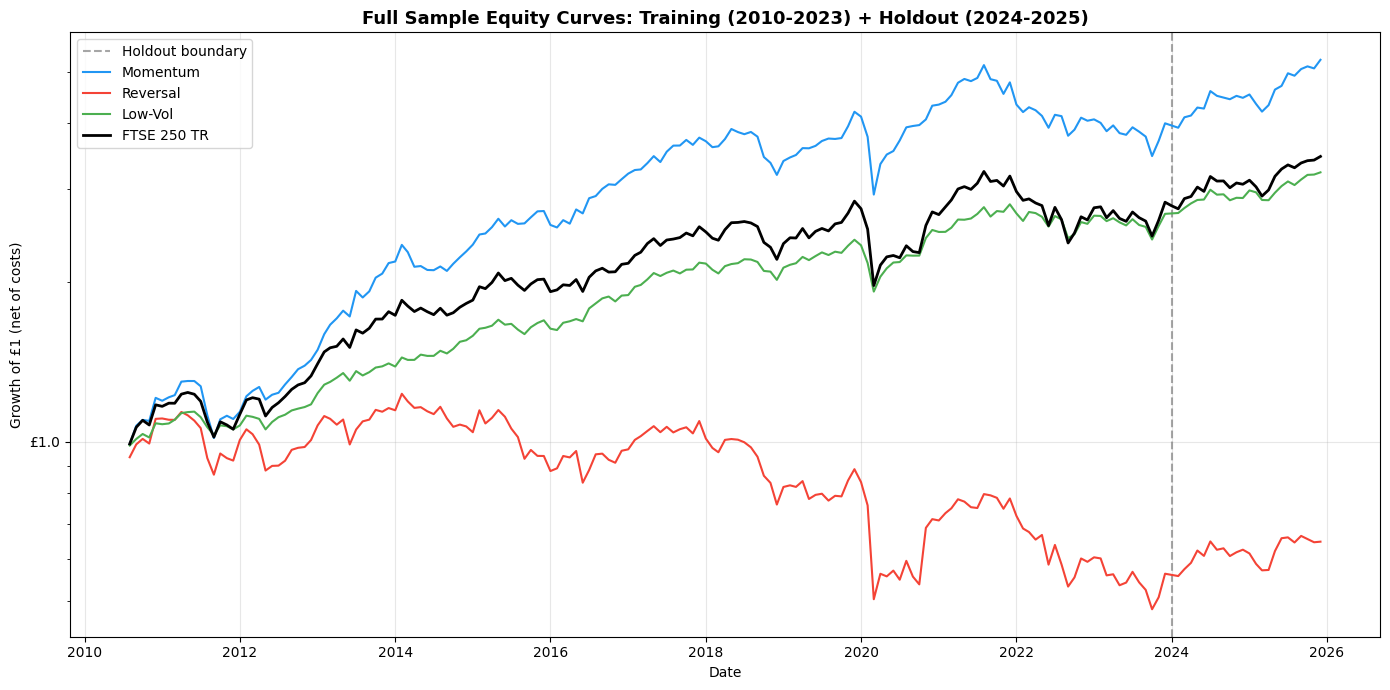

Chart saved to data/full_equity_curves.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Save holdout results
for name, df in holdout_net.items():
    safe_name = name.lower().replace(' ', '_').replace('+', 'plus')
    df.to_parquet(f'../data/working/holdout_{safe_name}.parquet')

# Combined equity curve: training + holdout
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_title('Full Sample Equity Curves: Training (2010-2023) + Holdout (2024-2025)',
             fontsize=13, fontweight='bold')

# Vertical line at holdout boundary
ax.axvline(x=pd.Timestamp('2024-01-01'), color='grey', linestyle='--', alpha=0.7, label='Holdout boundary')

# Load training results
train_results_data = {}
for name in ['Momentum', 'Reversal', 'Low-Vol']:
    safe = name.lower().replace('-', '-')
    tr = pd.read_parquet(f'../data/working/backtest_{safe.lower().replace("-", "-")}.parquet')
    train_results_data[name] = tr

colors = {'Momentum': '#2196F3', 'Reversal': '#F44336', 'Low-Vol': '#4CAF50'}

for name in ['Momentum', 'Reversal', 'Low-Vol']:
    # Training period
    tr = train_results_data[name]
    tr_cum = (1 + tr.set_index('holding_month')['port_ret_net']).cumprod()
   
    # Holdout period — chain onto training
    ho = holdout_net[name]
    ho_cum = (1 + ho.set_index('holding_month')['port_ret_net']).cumprod() * tr_cum.iloc[-1]
   
    # Combine
    full_cum = pd.concat([tr_cum, ho_cum])
    ax.plot(full_cum.index, full_cum.values, linewidth=1.5, color=colors[name], label=name)

# Benchmark
bench_full = (1 + bench_monthly_all.loc[bench_monthly_all.index >= '2010-08-01']).cumprod()
ax.plot(bench_full.index, bench_full.values, 'k-', linewidth=2, label='FTSE 250 TR')

ax.set_ylabel('Growth of £1 (net of costs)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:.1f}'))

plt.tight_layout()
plt.savefig('../data/full_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/full_equity_curves.png")

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

HOLDOUT_START = pd.Timestamp("2024-01-01")
HOLDOUT_END   = pd.Timestamp("2025-12-31")

strategy_files = {
    "Momentum (12-1)":   "data/working/canonical_momentum_12_1.parquet",
    "Low-Volatility":    "data/working/canonical_vol_90d.parquet",
    "Combined (Mom+LV)": "data/working/canonical_z_composite.parquet",
}

# ---- Load benchmark ----
bench_raw = pd.read_parquet(PROJECT_ROOT / "data/holdout_locked/benchmark_holdout.parquet")
bench = bench_raw[bench_raw["field"] == "TOT_RETURN_INDEX_GROSS_DVDS"].copy()
bench["date"] = pd.to_datetime(bench["date"])
bench = bench.sort_values("date").set_index("date")
bench_m = bench["value"].resample("ME").last().pct_change().dropna()
bench_m.index = pd.PeriodIndex(bench_m.index, freq="M").to_timestamp()
print(f"Benchmark monthly returns: {len(bench_m)} obs, range {bench_m.index.min().date()} to {bench_m.index.max().date()}")

# ---- Load SONIA ----
sonia_raw = pd.read_parquet(PROJECT_ROOT / "data/holdout_locked/sonia_holdout.parquet")
sonia = sonia_raw[sonia_raw["field"] == "PX_LAST"].copy()
sonia["date"] = pd.to_datetime(sonia["date"])
sonia = sonia.sort_values("date").set_index("date")
rf_m = (sonia["value"].resample("ME").mean() / 100.0 / 12.0)
rf_m.index = pd.PeriodIndex(rf_m.index, freq="M").to_timestamp()
print(f"SONIA monthly RF: {len(rf_m)} obs, mean {rf_m.mean():.4f}")
print()

# ---- Run regressions ----
print(f"{'Strategy':<22} {'α (ann)':>10} {'t (NW)':>10} {'Sig':>5} {'Max DD':>10} {'n':>4}")
print("-" * 65)

for name, rel_path in strategy_files.items():
    df = pd.read_parquet(PROJECT_ROOT / rel_path)
    df["month"] = pd.to_datetime(df["month"])
    df = df.set_index("month").sort_index()
    df = df.loc[HOLDOUT_START:HOLDOUT_END]

    port = pd.Series(df["net"].values,
                     index=pd.PeriodIndex(df.index, freq="M").to_timestamp(),
                     name="port")

    aligned = pd.concat([port, bench_m.rename("bench"), rf_m.rename("rf")],
                        axis=1, join="inner").dropna()

    if len(aligned) < 6:
        print(f"{name:<22} INSUFFICIENT DATA — only {len(aligned)} aligned obs")
        continue

    y = aligned["port"]  - aligned["rf"]
    x = aligned["bench"] - aligned["rf"]
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    alpha_m = model.params.iloc[0]
    alpha_a = (1 + alpha_m)**12 - 1
    t_alpha = model.tvalues.iloc[0]
    p_alpha = model.pvalues.iloc[0]
    sig = "***" if p_alpha < 0.01 else "**" if p_alpha < 0.05 else "*" if p_alpha < 0.10 else ""

    wealth = (1 + aligned["port"]).cumprod()
    max_dd = (wealth / wealth.cummax() - 1).min()

    print(f"{name:<22} {alpha_a*100:>9.2f}% {t_alpha:>10.2f} {sig:>5} {max_dd*100:>9.1f}% {len(aligned):>4}")

Benchmark monthly returns: 23 obs, range 2024-02-01 to 2025-12-01
SONIA monthly RF: 24 obs, mean 0.0039

Strategy                  α (ann)     t (NW)   Sig     Max DD    n
-----------------------------------------------------------------
Momentum (12-1)        INSUFFICIENT DATA — only 0 aligned obs
Low-Volatility         INSUFFICIENT DATA — only 0 aligned obs
Combined (Mom+LV)      INSUFFICIENT DATA — only 0 aligned obs


In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

HOLDOUT_START = pd.Timestamp("2024-01-01")
HOLDOUT_END   = pd.Timestamp("2025-12-31")

strategy_files = {
    "Momentum (12-1)":   "data/working/canonical_momentum_12_1.parquet",
    "Low-Volatility":    "data/working/canonical_vol_90d.parquet",
    "Combined (Mom+LV)": "data/working/canonical_z_composite.parquet",
}

for name, rel_path in strategy_files.items():
    df = pd.read_parquet(PROJECT_ROOT / rel_path)
    print(f"\n=== {name} ===")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Shape: {df.shape}")
    df["month"] = pd.to_datetime(df["month"])
    print(f"month range: {df['month'].min()} to {df['month'].max()}")
    print(f"First 3 rows:")
    print(df.head(3))
    print(f"Last 3 rows:")
    print(df.tail(3))
    # How many rows fall in the holdout window?
    in_holdout = df[(df["month"] >= HOLDOUT_START) & (df["month"] <= HOLDOUT_END)]
    print(f"Rows in holdout window [{HOLDOUT_START.date()}, {HOLDOUT_END.date()}]: {len(in_holdout)}")


=== Momentum (12-1) ===
Columns: ['month', 'gross', 'net', 'tc', 'n', 'signal']
Shape: (161, 6)
month range: 2010-08-01 00:00:00 to 2023-12-01 00:00:00
First 3 rows:
       month     gross       net        tc   n         signal
0 2010-08-01  0.000722 -0.004278  0.005000  50  momentum_12_1
1 2010-09-01  0.088319  0.087196  0.001122  49  momentum_12_1
2 2010-10-01  0.028247  0.027634  0.000612  49  momentum_12_1
Last 3 rows:
         month     gross       net      tc   n         signal
158 2023-10-01 -0.078766 -0.080266  0.0015  50  momentum_12_1
159 2023-11-01  0.070347  0.069347  0.0010  50  momentum_12_1
160 2023-12-01  0.080494  0.078894  0.0016  50  momentum_12_1
Rows in holdout window [2024-01-01, 2025-12-31]: 0

=== Low-Volatility ===
Columns: ['month', 'gross', 'net', 'tc', 'n', 'signal']
Shape: (161, 6)
month range: 2010-08-01 00:00:00 to 2023-12-01 00:00:00
First 3 rows:
       month     gross       net        tc   n   signal
0 2010-08-01 -0.009334 -0.014334  0.005000  51  vol

In [5]:
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
HOLDOUT_START = pd.Timestamp("2024-01-01")
HOLDOUT_END   = pd.Timestamp("2025-12-31")

# ---- Inspect first ----
for f in ["holdout_momentum.parquet", "holdout_low-vol.parquet", "holdout_reversal.parquet"]:
    df = pd.read_parquet(PROJECT_ROOT / "data/working" / f)
    print(f"\n=== {f} ===")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Shape:   {df.shape}")
    print(df.head(3))
    print(df.tail(3))


=== holdout_momentum.parquet ===
Columns: ['formation_month', 'holding_month', 'port_ret', 'n_stocks', 'n_with_returns', 'portfolio', 'turnover', 'spread_cost', 'tc_monthly', 'port_ret_net']
Shape:   (23, 10)
  formation_month holding_month  port_ret  n_stocks  n_with_returns  \
0      2024-01-01    2024-02-01 -0.008151        50              50   
1      2024-02-01    2024-03-01  0.048348        50              50   
2      2024-03-01    2024-04-01  0.010211        50              50   

                                           portfolio  turnover  spread_cost  \
0  [AML LN Equity, AO/ LN Equity, ATT LN Equity, ...      1.00     0.005953   
1  [AGT LN Equity, ALW LN Equity, AO/ LN Equity, ...      0.20     0.004576   
2  [AGT LN Equity, ALW LN Equity, AO/ LN Equity, ...      0.24     0.005118   

   tc_monthly  port_ret_net  
0    0.010953     -0.019104  
1    0.001915      0.046433  
2    0.002428      0.007783  
   formation_month holding_month  port_ret  n_stocks  n_with_returns

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
HOLDOUT_START = pd.Timestamp("2024-01-01")
HOLDOUT_END   = pd.Timestamp("2025-12-31")

strategy_files = {
    "Momentum (12-1)": "data/working/holdout_momentum.parquet",
    "Reversal (1m)":   "data/working/holdout_reversal.parquet",
    "Low-Volatility":  "data/working/holdout_low-vol.parquet",
}

# ---- Benchmark ----
bench_raw = pd.read_parquet(PROJECT_ROOT / "data/holdout_locked/benchmark_holdout.parquet")
bench = bench_raw[bench_raw["field"] == "TOT_RETURN_INDEX_GROSS_DVDS"].copy()
bench["date"] = pd.to_datetime(bench["date"])
bench = bench.sort_values("date").set_index("date")
bench_m = bench["value"].resample("ME").last().pct_change().dropna()
bench_m.index = pd.PeriodIndex(bench_m.index, freq="M").to_timestamp()

# ---- SONIA ----
sonia_raw = pd.read_parquet(PROJECT_ROOT / "data/holdout_locked/sonia_holdout.parquet")
sonia = sonia_raw[sonia_raw["field"] == "PX_LAST"].copy()
sonia["date"] = pd.to_datetime(sonia["date"])
sonia = sonia.sort_values("date").set_index("date")
rf_m = (sonia["value"].resample("ME").mean() / 100.0 / 12.0)
rf_m.index = pd.PeriodIndex(rf_m.index, freq="M").to_timestamp()

# ---- Build a Combined (½:½) holdout series from Mom + LV monthly nets ----
mom = pd.read_parquet(PROJECT_ROOT / strategy_files["Momentum (12-1)"]).set_index("holding_month")["port_ret_net"]
lv  = pd.read_parquet(PROJECT_ROOT / strategy_files["Low-Volatility"]).set_index("holding_month")["port_ret_net"]
mom.index = pd.to_datetime(mom.index); lv.index = pd.to_datetime(lv.index)
combined = ((mom + lv) / 2.0).rename("port_ret_net").to_frame()
combined["holding_month"] = combined.index
strategy_data = {
    "Momentum (12-1)": pd.read_parquet(PROJECT_ROOT / strategy_files["Momentum (12-1)"])[["holding_month", "port_ret_net"]],
    "Reversal (1m)":   pd.read_parquet(PROJECT_ROOT / strategy_files["Reversal (1m)"])[["holding_month", "port_ret_net"]],
    "Low-Volatility":  pd.read_parquet(PROJECT_ROOT / strategy_files["Low-Volatility"])[["holding_month", "port_ret_net"]],
    "Combined (½:½ avg)": combined.reset_index(drop=True)[["holding_month", "port_ret_net"]],
}

print(f"{'Strategy':<22} {'α (ann)':>10} {'t (NW)':>10} {'Sig':>5} {'Max DD':>10} {'n':>4}")
print("-" * 65)

for name, df in strategy_data.items():
    df = df.copy()
    df["holding_month"] = pd.to_datetime(df["holding_month"])
    df = df.set_index("holding_month").sort_index()
    df = df.loc[HOLDOUT_START:HOLDOUT_END]

    port = pd.Series(df["port_ret_net"].values,
                     index=pd.PeriodIndex(df.index, freq="M").to_timestamp(),
                     name="port")

    aligned = pd.concat([port, bench_m.rename("bench"), rf_m.rename("rf")],
                        axis=1, join="inner").dropna()

    if len(aligned) < 6:
        print(f"{name:<22} INSUFFICIENT DATA — only {len(aligned)} aligned obs")
        continue

    y = aligned["port"]  - aligned["rf"]
    x = aligned["bench"] - aligned["rf"]
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    alpha_m = model.params.iloc[0]
    alpha_a = (1 + alpha_m)**12 - 1
    t_alpha = model.tvalues.iloc[0]
    p_alpha = model.pvalues.iloc[0]
    sig = "***" if p_alpha < 0.01 else "**" if p_alpha < 0.05 else "*" if p_alpha < 0.10 else ""

    wealth = (1 + aligned["port"]).cumprod()
    max_dd = (wealth / wealth.cummax() - 1).min()

    print(f"{name:<22} {alpha_a*100:>9.2f}% {t_alpha:>10.2f} {sig:>5} {max_dd*100:>9.1f}% {len(aligned):>4}")

Strategy                  α (ann)     t (NW)   Sig     Max DD    n
-----------------------------------------------------------------
Momentum (12-1)             3.27%       1.67     *      -8.6%   23
Reversal (1m)              -4.22%      -1.63           -11.8%   23
Low-Volatility              0.82%       0.52            -4.5%   23
Combined (½:½ avg)          2.04%       1.70     *      -6.5%   23
